# Cardiac Pacemakers in Dogs with Bradyarrhythmias: Programming Parameters

Statistical analysis of ventricular impedance and stimulation thresholds over time.

**Methods Summary:**
- Group comparisons: percent change from baseline (T0), with branching assumption testing
- Trajectory analysis: linear mixed-effects model on conductance (1/impedance) with log-transformed time
- Post-hoc: Tukey's (parametric) or Games-Howell (non-parametric)

In [20]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import os

os.makedirs('figuras', exist_ok=True)

IMPEDANCE_COL = 'Impedância ohms (Ω) lead status'
TIME_BINS = [-1, 0, 7, 90, 547, 912, np.inf]
TIME_LABELS = ['T0', 'T1 (≤7d)', 'T2 (≤90d)', 'T3 (≤547d)', 'T4 (≤912d)', 'T5 (>912d)']
NUMERIC_COLS = [IMPEDANCE_COL, 'Amplit pulso', 'Duraç pulso', 'impedância Ω', 'V', 'ms']

## 1. Data Loading

In [21]:
url = 'https://raw.githubusercontent.com/caiohamamura/monica/main/PLANILHA_PM_2024.xlsx'
dados = pd.read_excel(url, sheet_name='Planilha 1 ', skiprows=1, header=0, decimal=',', engine='openpyxl')
dados.head()

,Nome,dias,Amplit pulso,Duraç pulso,Sensibilidade,Impedância ohms (Ω) lead status,V,ms,V x ms,mV,...,corrente uA,impedância Ω,Pace/Sense polarity,Margem amplitude,Marca,modelo,Diagnóstico,data implante,DIAGNÓSTICO ESTIMULAÇÃO,Unnamed: 24
0,1,0.0,3.50,0.40,2.8,950.0,0.5,0.4,0.20,NaN,...,11.26,158,BIPOLAR,2x,MEDTRONIC,Adapta ADSR01,BAVT,T0,NaN,NaN
1,1,6.0,3.50,0.46,2.8,564.0,0.5,0.46,0.23,"8 - 11,2",...,13.83,109,BIPOLAR,2x,MEDTRONIC,NaN,NaN,T1,NaN,NaN
2,1,40.0,3.50,0.46,2,573.0,0.25,1,0.25,"5,6 - 8,0",...,13.71,110,BIPOLAR,2x,MEDTRONIC,NaN,NaN,T2,ver stored strip p s,NaN
3,1,222.0,2.25,0.40,2,509.0,1.125,0.4,0.45,"11,2 - 15,68",...,9.99,132,BIPOLAR,2x,MEDTRONIC,NaN,NaN,T3,NaN,NaN
4,1,908.0,2.25,0.40,2,445.0,0.75,0.4,0.30,"2,00 - 2,80",...,10.58,497,BIPOLAR,2x,MEDTRONIC,NaN,NaN,T4,ver stored strip p s,imprimir vários gráficos


## 2. Data Cleaning

In [22]:
df = dados[dados['dias'].notna()].copy()
df['dias'] = df['dias'].astype(int)
df['Nome'] = df['Nome'].astype(str)

df.loc[:, NUMERIC_COLS] = (
    df.loc[:, NUMERIC_COLS]
    .apply(lambda x: x.astype(str).str.replace(',', '.').replace(r'[^\d.]+', 'nan', regex=True))
    .astype(float)
)

df.head()

,Nome,dias,Amplit pulso,Duraç pulso,Sensibilidade,Impedância ohms (Ω) lead status,V,ms,V x ms,mV,...,corrente uA,impedância Ω,Pace/Sense polarity,Margem amplitude,Marca,modelo,Diagnóstico,data implante,DIAGNÓSTICO ESTIMULAÇÃO,Unnamed: 24
0,1,0,3.50,0.40,2.8,950.0,0.5,0.4,0.20,NaN,...,11.26,158.0,BIPOLAR,2x,MEDTRONIC,Adapta ADSR01,BAVT,T0,NaN,NaN
1,1,6,3.50,0.46,2.8,564.0,0.5,0.46,0.23,"8 - 11,2",...,13.83,109.0,BIPOLAR,2x,MEDTRONIC,NaN,NaN,T1,NaN,NaN
2,1,40,3.50,0.46,2,573.0,0.25,1.0,0.25,"5,6 - 8,0",...,13.71,110.0,BIPOLAR,2x,MEDTRONIC,NaN,NaN,T2,ver stored strip p s,NaN
3,1,222,2.25,0.40,2,509.0,1.125,0.4,0.45,"11,2 - 15,68",...,9.99,132.0,BIPOLAR,2x,MEDTRONIC,NaN,NaN,T3,NaN,NaN
4,1,908,2.25,0.40,2,445.0,0.75,0.4,0.30,"2,00 - 2,80",...,10.58,497.0,BIPOLAR,2x,MEDTRONIC,NaN,NaN,T4,ver stored strip p s,imprimir vários gráficos


In [23]:
df['Classe'] = pd.cut(df['dias'], TIME_BINS, labels=TIME_LABELS, include_lowest=True)
df[['Nome', 'dias', 'Classe', IMPEDANCE_COL]].head(12)

,Nome,dias,Classe,Impedância ohms (Ω) lead status
0,1,0,T0,950.0
1,1,6,T1 (≤7d),564.0
2,1,40,T2 (≤90d),573.0
3,1,222,T3 (≤547d),509.0
4,1,908,T4 (≤912d),445.0
5,1,1399,T5 (>912d),454.0
6,2,0,T0,621.0
7,2,7,T1 (≤7d),525.0
8,2,43,T2 (≤90d),465.0
9,2,287,T3 (≤547d),418.0


## 3. Descriptive Statistics

In [24]:
df[[c for c in ['dias', 'Amplit pulso', 'Duraç pulso', IMPEDANCE_COL, 'V x ms', 'meses'] if c in df.columns]].describe()

,dias,Amplit pulso,Duraç pulso,Impedância ohms (Ω) lead status,V x ms,meses
count,35.000000,35.000000,35.000000,35.000000,26.000000,35.000000
mean,192.142857,3.607143,0.560000,671.628571,0.498077,83.142857
std,371.979849,1.105278,0.284088,398.322444,0.640988,33.623471
min,0.000000,2.000000,0.400000,400.000000,0.160000,24.000000
25%,0.000000,3.000000,0.400000,489.500000,0.207500,57.000000
50%,7.000000,3.500000,0.400000,564.000000,0.310000,79.000000
75%,195.000000,4.750000,0.610000,706.000000,0.430000,104.000000
max,1399.000000,6.000000,1.500000,2691.000000,3.250000,162.000000


In [25]:
summary = df.groupby('Classe', observed=False)[IMPEDANCE_COL].agg(['mean', 'std', 'median', 'count'])
summary.columns = ['Mean (Ω)', 'SD', 'Median (Ω)', 'n']
summary

,Mean (Ω),SD,Median (Ω),n
Classe,,,,
T0,873.818182,615.456386,702.0,11
T1 (≤7d),668.285714,256.504525,564.0,7
T2 (≤90d),580.000000,118.005650,565.0,7
T3 (≤547d),573.500000,254.805612,482.0,6
T4 (≤912d),431.000000,19.798990,431.0,2
T5 (>912d),427.000000,38.183766,427.0,2


## 4. Impedance Trajectory Over Time

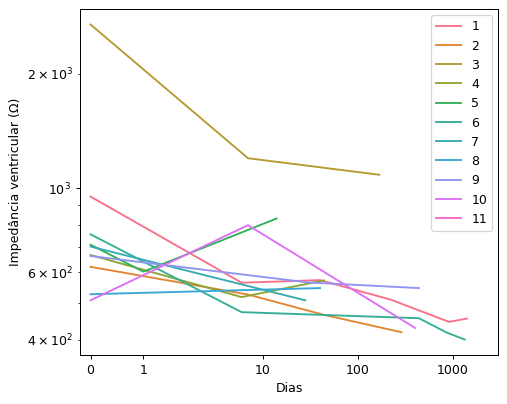

In [26]:
fig, ax = plt.subplots(figsize=(6, 5), dpi=90)
p = sns.lineplot(data=df, x='dias', y=IMPEDANCE_COL, hue='Nome', ax=ax)
p.set_xscale('symlog')
p.set_yscale('log')
p.set_ylabel('Impedância ventricular (Ω)')
p.set_xlabel('Dias')
p.legend_.set_title('')
p.set_xlim(-0.2, 3000)
p.set_xticks([0, 1, 10, 100, 1000])
p.set_xticklabels(['0', '1', '10', '100', '1000'])
plt.savefig('figuras/Impedancia ventricular por cao.pdf')
plt.show()

## 5. Boxplot: Ventricular Impedance by Time Band

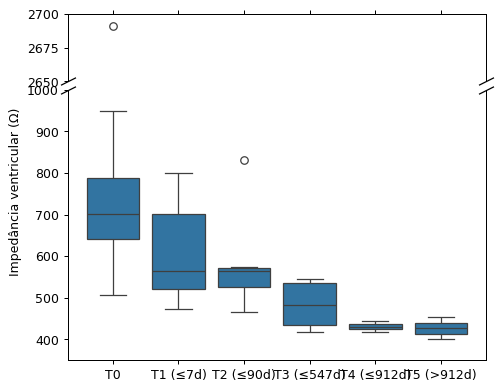

In [27]:
fig = plt.figure(figsize=(6, 5), dpi=90)
gs = fig.add_gridspec(2, 1, height_ratios=[0.2, 0.8], hspace=0.05)
ax_top = fig.add_subplot(gs[0])
ax_bot = fig.add_subplot(gs[1], sharex=ax_top)

for ax in [ax_top, ax_bot]:
    sns.boxplot(data=df, x='Classe', y=IMPEDANCE_COL, ax=ax)

ax_top.set_xlabel('')
ax_top.set_ylabel('')
ax_bot.set_xlabel('')
ax_bot.set_ylabel('Impedância ventricular (Ω)', y=0.625)
ax_top.set_ylim(2650, 2700)
ax_bot.set_ylim(350, 1000)
ax_top.spines.bottom.set_visible(False)
ax_bot.spines.top.set_visible(False)
ax_top.xaxis.tick_top()
ax_top.tick_params(labeltop=False)
ax_bot.xaxis.tick_bottom()

d = 0.5
kwargs = dict(marker=[(-1, -d), (1, d)], markersize=12,
              linestyle='none', color='k', mec='k', mew=1, clip_on=False)
ax_top.plot([0, 1], [0, 0], transform=ax_top.transAxes, **kwargs)
ax_bot.plot([0, 1], [1, 1], transform=ax_bot.transAxes, **kwargs)
plt.savefig('figuras/boxplotImpedanciaVentricular.pdf')
plt.show()

## 6. Conversion to conductance in millisiemens (mS)

Use conductance in millisiemens, which behaves more normally distributed and is significant as it measures the conductance factor instead of the resistance to current.

In [109]:
baselines = df[df['dias'] == 0].set_index('Nome')[IMPEDANCE_COL]


df['conductance'] = 1000 / df[IMPEDANCE_COL]
df[['Nome', 'dias', 'Classe', IMPEDANCE_COL, 'conductance']].head(12)

,Nome,dias,Classe,Impedância ohms (Ω) lead status,conductance
0,1,0,T0,950.0,1.052632
1,1,6,T1 (≤7d),564.0,1.773050
2,1,40,T2 (≤90d),573.0,1.745201
3,1,222,T3 (≤547d),509.0,1.964637
4,1,908,T4 (≤912d),445.0,2.247191
5,1,1399,T5 (>912d),454.0,2.202643
6,2,0,T0,621.0,1.610306
7,2,7,T1 (≤7d),525.0,1.904762
8,2,43,T2 (≤90d),465.0,2.150538
9,2,287,T3 (≤547d),418.0,2.392344


## 7. Group Comparisons: Assumption Testing & Statistical Tests

Decision tree:
- Test normality (Shapiro-Wilk) and homogeneity of variance (Levene's)
- If assumptions met → ANOVA + Tukey's post hoc
- If assumptions violated → Kruskal-Wallis + Games-Howell post hoc

## Helper function

In [137]:
def anova_kruskal_analysis(column):
    # Group filtering
    df_analysis = df[df['dias'] < 547].copy()

    groups = {}
    for label in TIME_LABELS:
        data = df_analysis[df_analysis['Classe'] == label][column].dropna()
        if len(data) >= 3:
            groups[label] = data
        else:
            print(f"Excluded '{label}': n={len(data)} < 3")

    print(f"\nGroups for analysis:")
    for label, data in groups.items():
        print(f"  {label}: n={len(data)}")

    # Shapiro normality test
    print(f"Shapiro-Wilk Normality Test ({column}):\n")
    normality_ok = True
    for label, data in groups.items():
        stat, p = stats.shapiro(data)
        status = 'Normal' if p > 0.05 else 'Non-normal'
        print(f"  {label}: n={len(data)}, W={stat:.3f}, p={p:.3f} -> {status}")
        if p <= 0.05:
            normality_ok = False
    print(f"\nOverall normality: {'PASS' if normality_ok else 'FAIL'}")

    # Levene homoscedasticity
    group_values = list(groups.values())
    levene_stat, levene_p = stats.levene(*group_values)
    variance_ok = levene_p > 0.05

    print(f"Levene's Test: F={levene_stat:.3f}, p={levene_p:.3f}")
    print(f"  -> Homogeneity of variances: {'PASS' if variance_ok else 'FAIL'} (p {'>' if variance_ok else '<'} 0.05)")


    # ANOVA/Kruskal
    if normality_ok and variance_ok:
        print('='*60)
        print('Parametric assumptions MET -> ANOVA + Tukey HSD')
        print('='*60)
        f_stat, p_value = stats.f_oneway(*group_values)
        print(f"\nOne-Way ANOVA: F={f_stat:.3f}, p={p_value:.4f}")

        if p_value < 0.05:
            from statsmodels.stats.multicomp import pairwise_tukeyhsd
            tukey_df = pd.concat([pd.DataFrame({'value': v, 'group': k}) for k, v in groups.items()])
            tukey = pairwise_tukeyhsd(tukey_df['value'], tukey_df['group'], alpha=0.05)
            print("\nTukey's Post-Hoc:")
            print(tukey)
        else:
            print("No significant differences found (p >= 0.05).")
    else:
        print('='*60)
        print('Parametric assumptions VIOLATED -> Kruskal-Wallis + Games-Howell')
        print('='*60)
        h_stat, p_kw = stats.kruskal(*group_values)
        print(f"\nKruskal-Wallis: H={h_stat:.3f}, p={p_kw:.4f}")

        if p_kw < 0.05:
            try:
                import pingouin as pg
            except ImportError:
                !pip install pingouin
                import pingouin as pg

            posthoc_df = pd.concat([pd.DataFrame({'value': v, 'group': k}) for k, v in groups.items()])
            posthoc = pg.pairwise_gameshowell(data=posthoc_df, dv='value', between='group')
            print("\nGames-Howell Post-Hoc:")
            display(posthoc)
        else:
            print("No significant differences found (p >= 0.05).")
    

## Conductance

In [138]:
anova_kruskal_analysis('conductance')

Excluded 'T4 (≤912d)': n=0 < 3
Excluded 'T5 (>912d)': n=0 < 3

Groups for analysis:
  T0: n=11
  T1 (≤7d): n=7
  T2 (≤90d): n=7
  T3 (≤547d): n=6
Shapiro-Wilk Normality Test (conductance):

  T0: n=11, W=0.907, p=0.222 -> Normal
  T1 (≤7d): n=7, W=0.902, p=0.342 -> Normal
  T2 (≤90d): n=7, W=0.879, p=0.222 -> Normal
  T3 (≤547d): n=6, W=0.831, p=0.110 -> Normal

Overall normality: PASS
Levene's Test: F=0.417, p=0.742
  -> Homogeneity of variances: PASS (p > 0.05)
Parametric assumptions MET -> ANOVA + Tukey HSD

One-Way ANOVA: F=2.411, p=0.0888
No significant differences found (p >= 0.05).


## Stimulation Threshold: pulse amplitude

In [140]:
anova_kruskal_analysis('Amplit pulso')

Excluded 'T4 (≤912d)': n=0 < 3
Excluded 'T5 (>912d)': n=0 < 3

Groups for analysis:
  T0: n=11
  T1 (≤7d): n=7
  T2 (≤90d): n=7
  T3 (≤547d): n=6
Shapiro-Wilk Normality Test (Amplit pulso):

  T0: n=11, W=0.754, p=0.002 -> Non-normal
  T1 (≤7d): n=7, W=0.953, p=0.755 -> Normal
  T2 (≤90d): n=7, W=0.965, p=0.859 -> Normal
  T3 (≤547d): n=6, W=0.880, p=0.268 -> Normal

Overall normality: FAIL
Levene's Test: F=0.413, p=0.745
  -> Homogeneity of variances: PASS (p > 0.05)
Parametric assumptions VIOLATED -> Kruskal-Wallis + Games-Howell

Kruskal-Wallis: H=2.210, p=0.5301
No significant differences found (p >= 0.05).


## Battery-life: months to ERI

In [141]:
anova_kruskal_analysis('meses')

Excluded 'T4 (≤912d)': n=0 < 3
Excluded 'T5 (>912d)': n=0 < 3

Groups for analysis:
  T0: n=11
  T1 (≤7d): n=7
  T2 (≤90d): n=7
  T3 (≤547d): n=6
Shapiro-Wilk Normality Test (meses):

  T0: n=11, W=0.963, p=0.810 -> Normal
  T1 (≤7d): n=7, W=0.870, p=0.187 -> Normal
  T2 (≤90d): n=7, W=0.990, p=0.994 -> Normal
  T3 (≤547d): n=6, W=0.824, p=0.096 -> Normal

Overall normality: PASS
Levene's Test: F=0.938, p=0.436
  -> Homogeneity of variances: PASS (p > 0.05)
Parametric assumptions MET -> ANOVA + Tukey HSD

One-Way ANOVA: F=0.542, p=0.6574
No significant differences found (p >= 0.05).


## 8. Linear Mixed-Effects Model

Raw impedance converted to **conductance (1/Z)** to linearize the biological response to post-implantation healing. This is physically defensible via Ohm's Law: while impedance scales non-linearly as fibrotic tissue grows, conductance scales linearly with the conductive tissue cross-sectional area.

**Model:** Conductance ~ log(Days + 1) + (1 | Dog)

In [155]:
import statsmodels.formula.api as smf
df['log_days'] = np.log1p(df['dias'])

model = smf.mixedlm('conductance ~ log_days', df, groups='Nome')
result = model.fit(reml=False)
print(result.summary())

          Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: conductance
No. Observations: 35      Method:             ML         
No. Groups:       11      Scale:              0.0572     
Min. group size:  1       Log-Likelihood:     -9.2238    
Max. group size:  6       Converged:          Yes        
Mean group size:  3.2                                    
----------------------------------------------------------
            Coef.  Std.Err.    z     P>|z|  [0.025  0.975]
----------------------------------------------------------
Intercept   1.395     0.111  12.579  0.000   1.177   1.612
log_days    0.108     0.018   6.101  0.000   0.074   0.143
Nome Var    0.093     0.241                               



### Fixed Effects Summary

Intercept and slope estimates with 95% confidence intervals for the population-level (fixed) effects.

In [156]:
fe = result.fe_params
se = result.bse_fe
z = result.tvalues
p = result.pvalues
ci = result.conf_int()

fe_table = pd.DataFrame({
    'Estimate': fe,
    'Std.Error': se,
    'z': z,
    'P>|z|': p,
    '95% CI Lower': ci[0],
    '95% CI Upper': ci[1]
})


fe_table.iloc[[0,2]]

,Estimate,Std.Error,z,P>|z|,95% CI Lower,95% CI Upper
Intercept,1.394723,0.110875,12.579240,2.746606e-36,1.177412,1.612034
log_days,0.108429,0.017772,6.101086,1.053500e-09,0.073596,0.143261


### Per-Dog Random Intercepts (BLUPs)

Best Linear Unbiased Predictors (BLUPs) showing how each dog's baseline conductance deviates from the population mean.

In [157]:
result.fe_params

Intercept    1.394723
log_days     0.108429
dtype: float64

In [158]:
s

4    -0.675937
2     0.000992
6     0.029852
10    0.079042
0     0.092248
8     0.201028
5     0.211782
1     0.245468
9     0.314980
7     0.318586
3     0.374673
dtype: float64

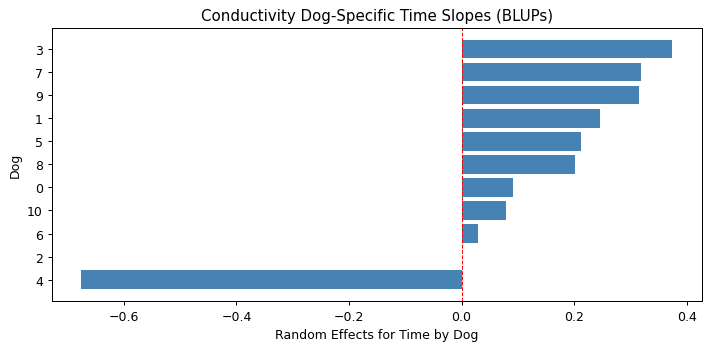

In [159]:
fixed_slope = result.fe_params["log_days"]

individual_slopes = {
    group: fixed_slope + effects["Nome"]
    for group, effects in result.random_effects.items()
}

s = pd.Series(individual_slopes.values()).sort_values()


fig, ax = plt.subplots(figsize=(8, 4), dpi=90)
ax.barh(s.index.astype(str), s, color='steelblue')
ax.axvline(0, linestyle='--', color='red', linewidth=0.8)
ax.set_xlabel('Random Effects for Time by Dog')
ax.set_ylabel('Dog')
ax.set_title("Conductivity Dog-Specific Time Slopes (BLUPs)")
plt.tight_layout()
plt.savefig('figuras/random_slopes_bar_conductivity.pdf')
plt.show()

### Mixed Model Diagnostics

Assumptions checked on **residuals** (not raw data):
1. Normality of residuals (Q-Q plot + Shapiro-Wilk)
2. Homoscedasticity (residuals vs fitted values)
3. Normality of random effects (Q-Q plot of random intercepts)

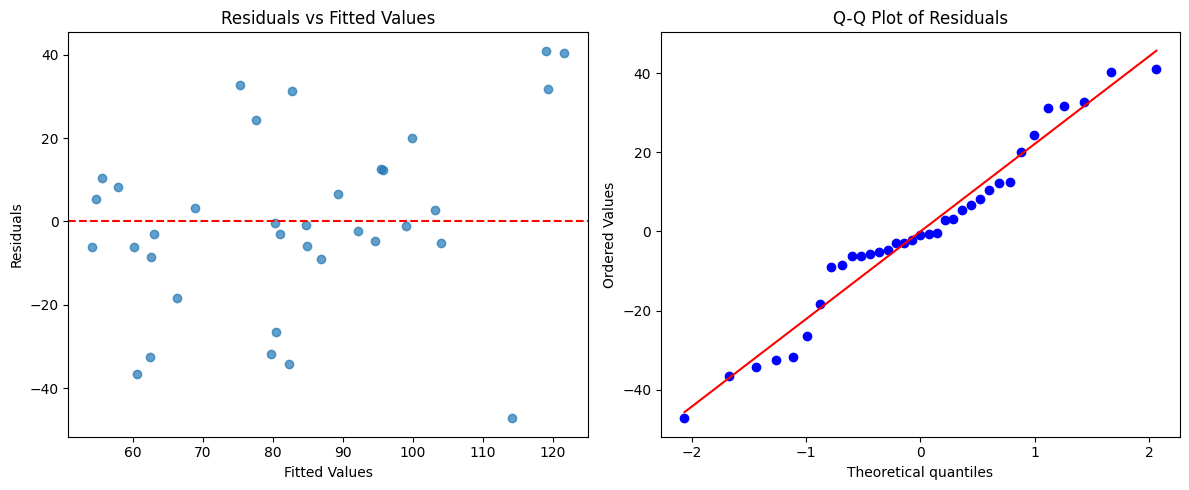

In [125]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(result.fittedvalues, result.resid, alpha=0.7)
axes[0].axhline(0, linestyle='--', color='red')
axes[0].set_xlabel('Fitted Values')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Fitted Values')

stats.probplot(result.resid, dist='norm', plot=axes[1])
axes[1].set_title('Q-Q Plot of Residuals')

plt.tight_layout()
plt.savefig('figuras/mixed_model_diagnostics_conductance.pdf')
plt.show()

In [51]:
stat, p = stats.shapiro(result.resid)
print(f'Shapiro-Wilk on residuals: W={stat:.3f}, p={p:.3f}')
print(f'  -> Residuals are {"normally" if p > 0.05 else "not normally"} distributed (p {">" if p > 0.05 else "<="} 0.05)')

Shapiro-Wilk on residuals: W=0.983, p=0.850
  -> Residuals are normally distributed (p > 0.05)


### Pulse Amplitude

In [142]:
import statsmodels.formula.api as smf

model = smf.mixedlm('Q("Amplit pulso") ~ log_days', df, groups='Nome')
result = model.fit(reml=False)
print(result.summary())

             Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: Q("Amplit pulso")
No. Observations: 35      Method:             ML               
No. Groups:       11      Scale:              0.6709           
Min. group size:  1       Log-Likelihood:     -47.3520         
Max. group size:  6       Converged:          Yes              
Mean group size:  3.2                                          
-----------------------------------------------------------------
             Coef.    Std.Err.     z      P>|z|   [0.025   0.975]
-----------------------------------------------------------------
Intercept     4.182      0.268   15.589   0.000    3.656    4.708
log_days     -0.190      0.059   -3.222   0.001   -0.306   -0.074
Nome Var      0.297      0.340                                   



log_days p-value is statistically significant!

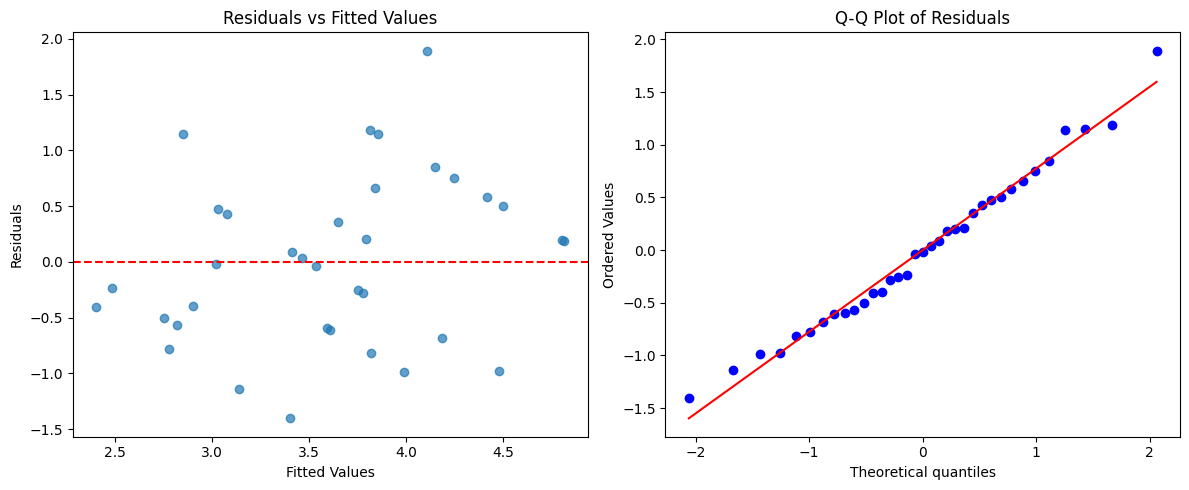

In [143]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(result.fittedvalues, result.resid, alpha=0.7)
axes[0].axhline(0, linestyle='--', color='red')
axes[0].set_xlabel('Fitted Values')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Fitted Values')

stats.probplot(result.resid, dist='norm', plot=axes[1])
axes[1].set_title('Q-Q Plot of Residuals')

plt.tight_layout()
plt.savefig('figuras/mixed_model_diagnostics_amplit_pulse.pdf')
plt.show()

In [144]:
stat, p = stats.shapiro(result.resid)
print(f'Shapiro-Wilk on residuals: W={stat:.3f}, p={p:.3f}')
print(f'  -> Residuals are {"normally" if p > 0.05 else "not normally"} distributed (p {">" if p > 0.05 else "<="} 0.05)')

Shapiro-Wilk on residuals: W=0.984, p=0.877
  -> Residuals are normally distributed (p > 0.05)


In [145]:
model = smf.mixedlm('Q("meses") ~ log_days', df, groups='Nome')
result = model.fit(reml=False)
print(result.summary())

         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: Q("meses")
No. Observations: 35      Method:             ML        
No. Groups:       11      Scale:              593.9622  
Min. group size:  1       Log-Likelihood:     -168.6581 
Max. group size:  6       Converged:          Yes       
Mean group size:  3.2                                   
--------------------------------------------------------
             Coef.  Std.Err.   z    P>|z| [0.025  0.975]
--------------------------------------------------------
Intercept    90.412    9.459  9.558 0.000 71.872 108.952
log_days     -1.226    1.813 -0.676 0.499 -4.781   2.328
Nome Var    542.923   17.414                            



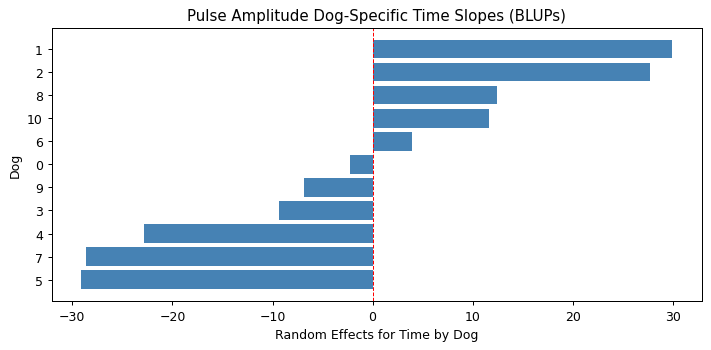

In [149]:
fixed_slope = result.fe_params["log_days"]

individual_slopes = {
    group: fixed_slope + effects["Nome"]
    for group, effects in result.random_effects.items()
}

s = pd.Series(individual_slopes.values()).sort_values()


fig, ax = plt.subplots(figsize=(8, 4), dpi=90)
ax.barh(s.index.astype(str), s, color='steelblue')
ax.axvline(0, linestyle='--', color='red', linewidth=0.8)
ax.set_xlabel('Random Effects for Time by Dog')
ax.set_ylabel('Dog')
ax.set_title("Pulse Amplitude Dog-Specific Time Slopes (BLUPs)")
plt.tight_layout()
plt.savefig('figuras/random_slopes_bar_pulse_amplitude.pdf')
plt.show()

### Battery duration estimate: months until Elective Replacement Indicator (ERI)

In [ ]:
model = smf.mixedlm('meses ~ log_days', df, groups='Nome')
result = model.fit(reml=False)
print(result.summary())

         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: meses    
No. Observations: 35      Method:             ML       
No. Groups:       11      Scale:              593.9622 
Min. group size:  1       Log-Likelihood:     -168.6581
Max. group size:  6       Converged:          Yes      
Mean group size:  3.2                                  
-------------------------------------------------------
            Coef.  Std.Err.   z    P>|z| [0.025  0.975]
-------------------------------------------------------
Intercept   90.412    9.459  9.558 0.000 71.872 108.952
log_days    -1.226    1.813 -0.676 0.499 -4.781   2.328
Nome Var   542.923   17.414                            



Not significant log_days intercept, no need to check model residuals to ensure model is valid